## Hepatocyte

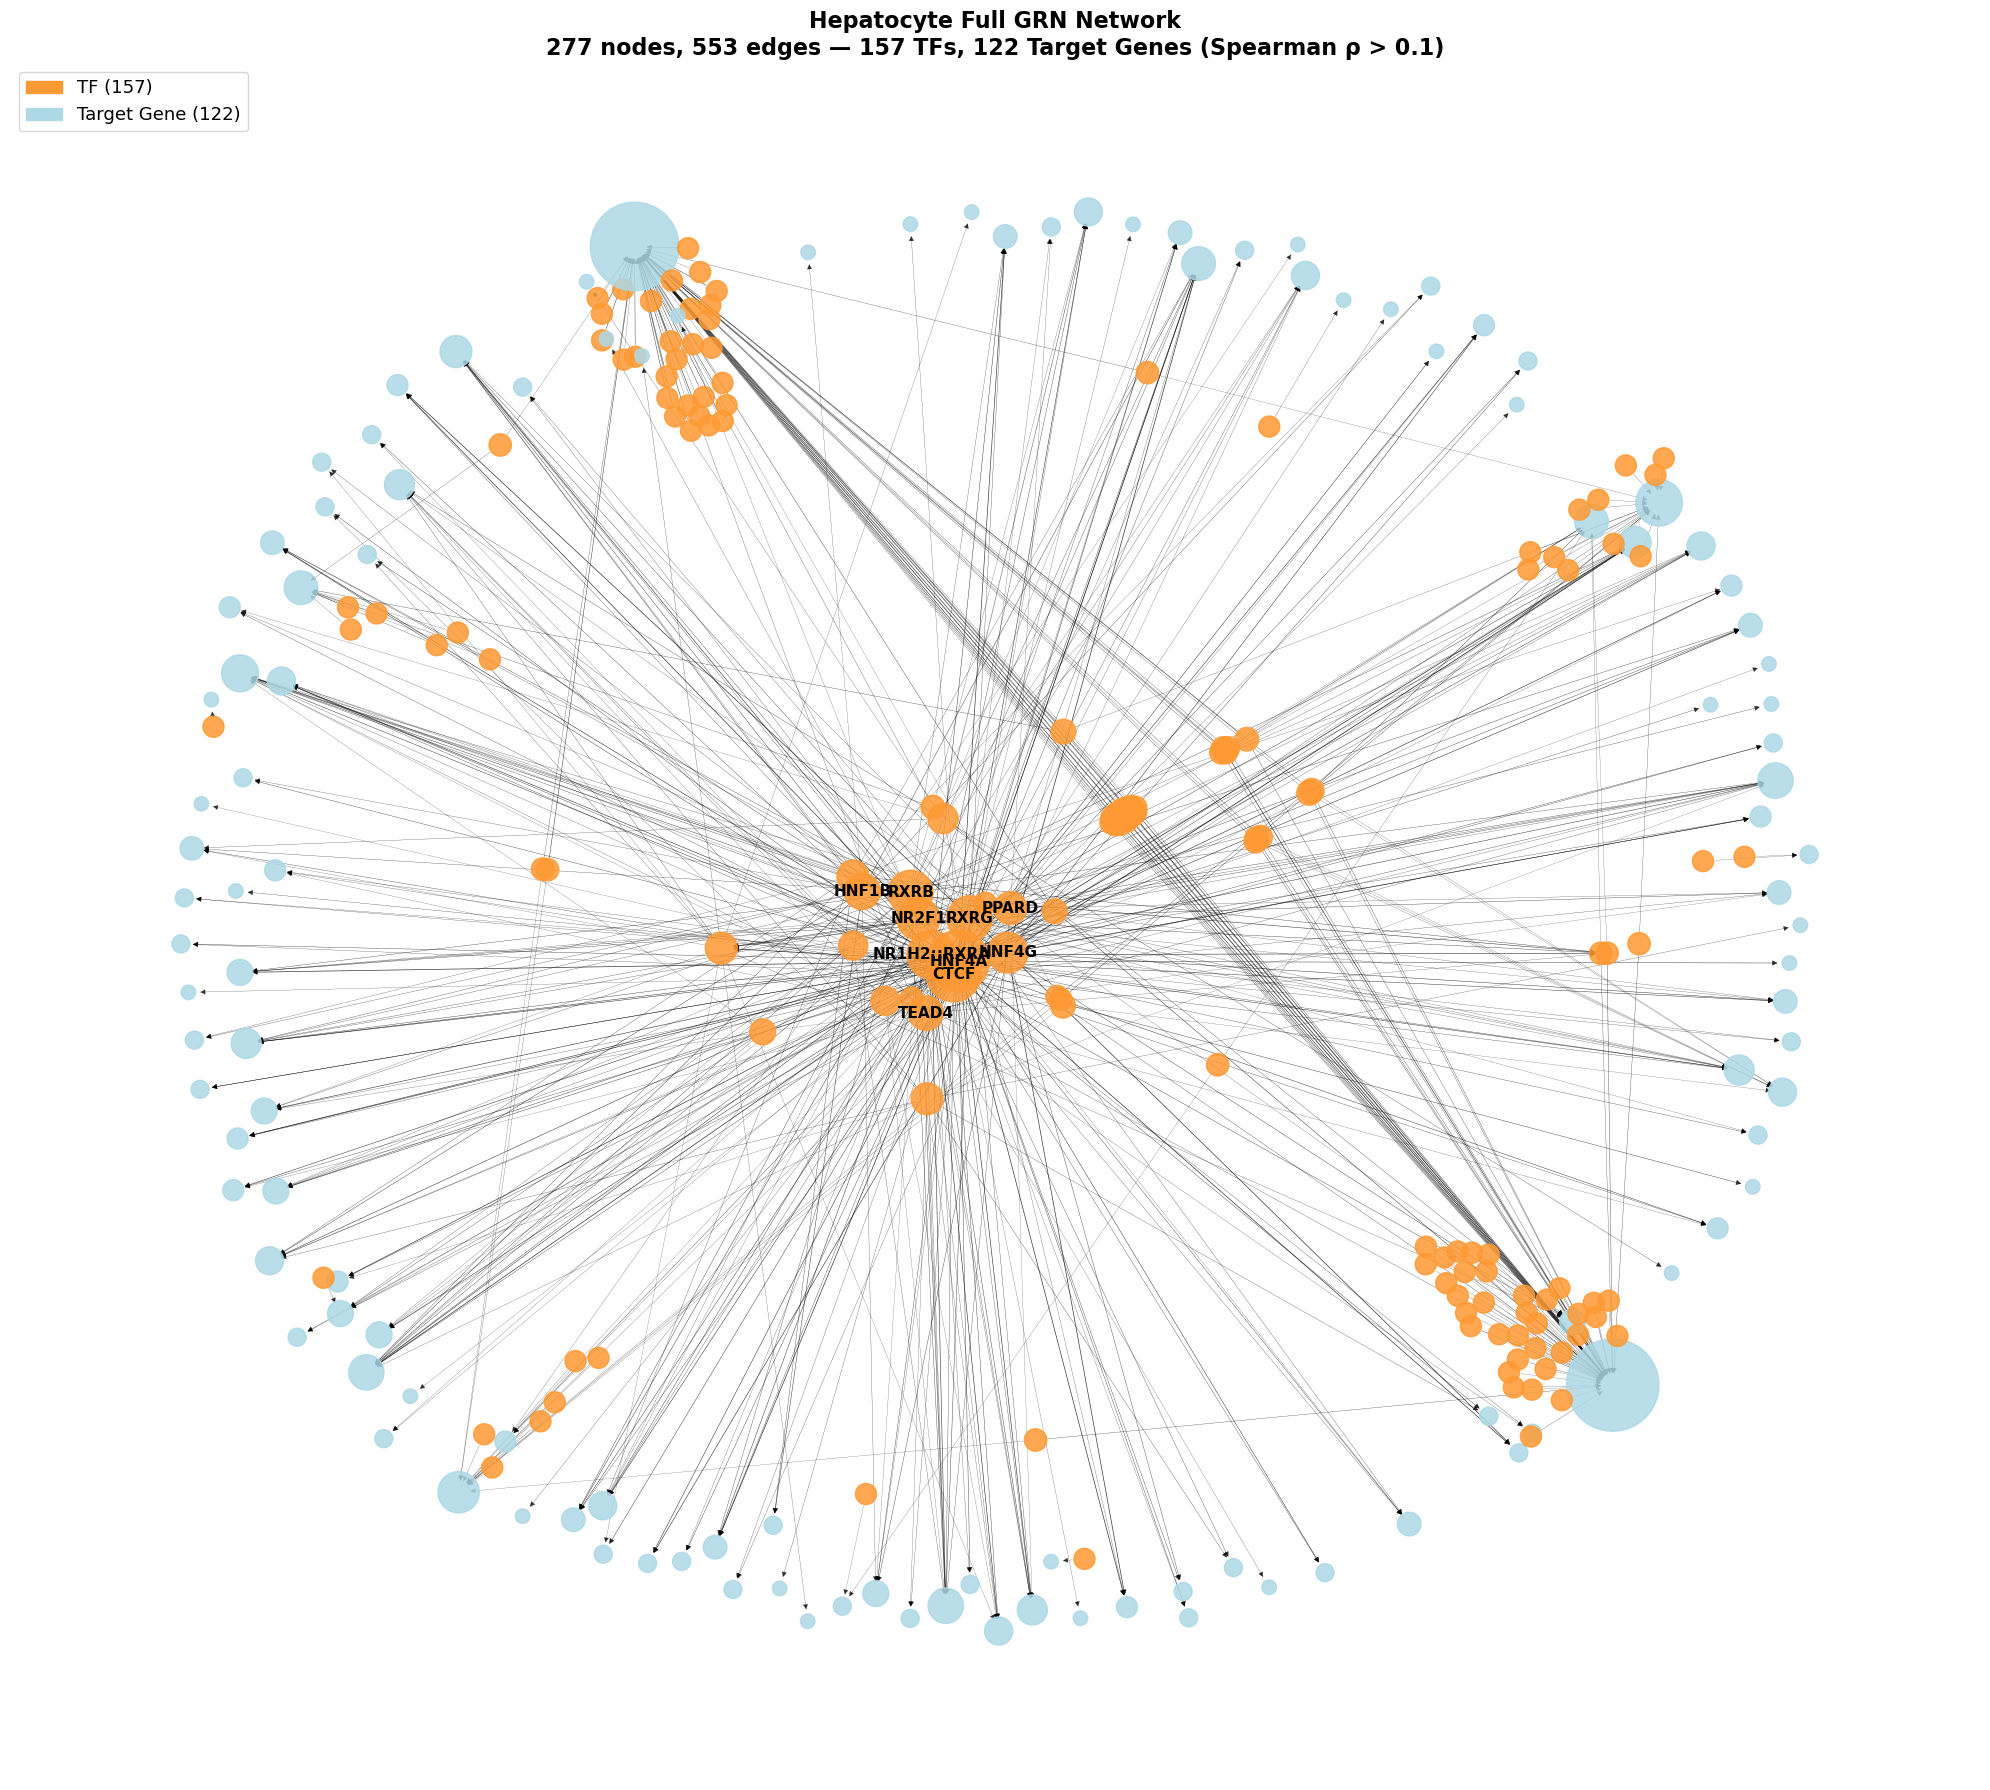

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 데이터 로드 및 필터링
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/All_GRN_Weights_Hepatocytes.csv')
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 2. 전체 네트워크 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], grn_weight=row['grn_weight'])

# 3. 노드 속성
tfs = set(filtered_df['tf_name'])
targets = set(filtered_df['gene'])
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Top 10 TF (라벨 표시용)
top10_tfs = sorted([n for n in G.nodes() if n in tfs], key=lambda x: out_degree.get(x, 0), reverse=True)[:10]

# 4. 전체 네트워크 시각화
plt.figure(figsize=(20, 18))
pos = nx.spring_layout(G, k=0.15, iterations=80, seed=42)

# 노드 색상, 크기
node_color = ['#FF9933' if n in tfs else '#ADD8E6' for n in G.nodes()]
node_size = []
for n in G.nodes():
    if n in tfs:
        node_size.append(out_degree.get(n, 1) * 30 + 200)
    else:
        node_size.append(in_degree.get(n, 1) * 60 + 50)

# 에지
weights = [d['grn_weight'] * 1.5 for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#000000', alpha=0.8, arrowsize=8)

# 노드
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.85)

# 라벨: Top 10 TF만
labels = {n: n for n in top10_tfs}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')

# 범례
orange_patch = mpatches.Patch(color='#FF9933', label=f'TF ({len(tfs)})')
blue_patch = mpatches.Patch(color='#ADD8E6', label=f'Target Gene ({len(targets)})')
plt.legend(handles=[orange_patch, blue_patch], fontsize=13, loc='upper left')

plt.title(f'Hepatocyte Full GRN Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges — {len(tfs)} TFs, {len(targets)} Target Genes (Spearman ρ > 0.1)',
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Mesenchymal 

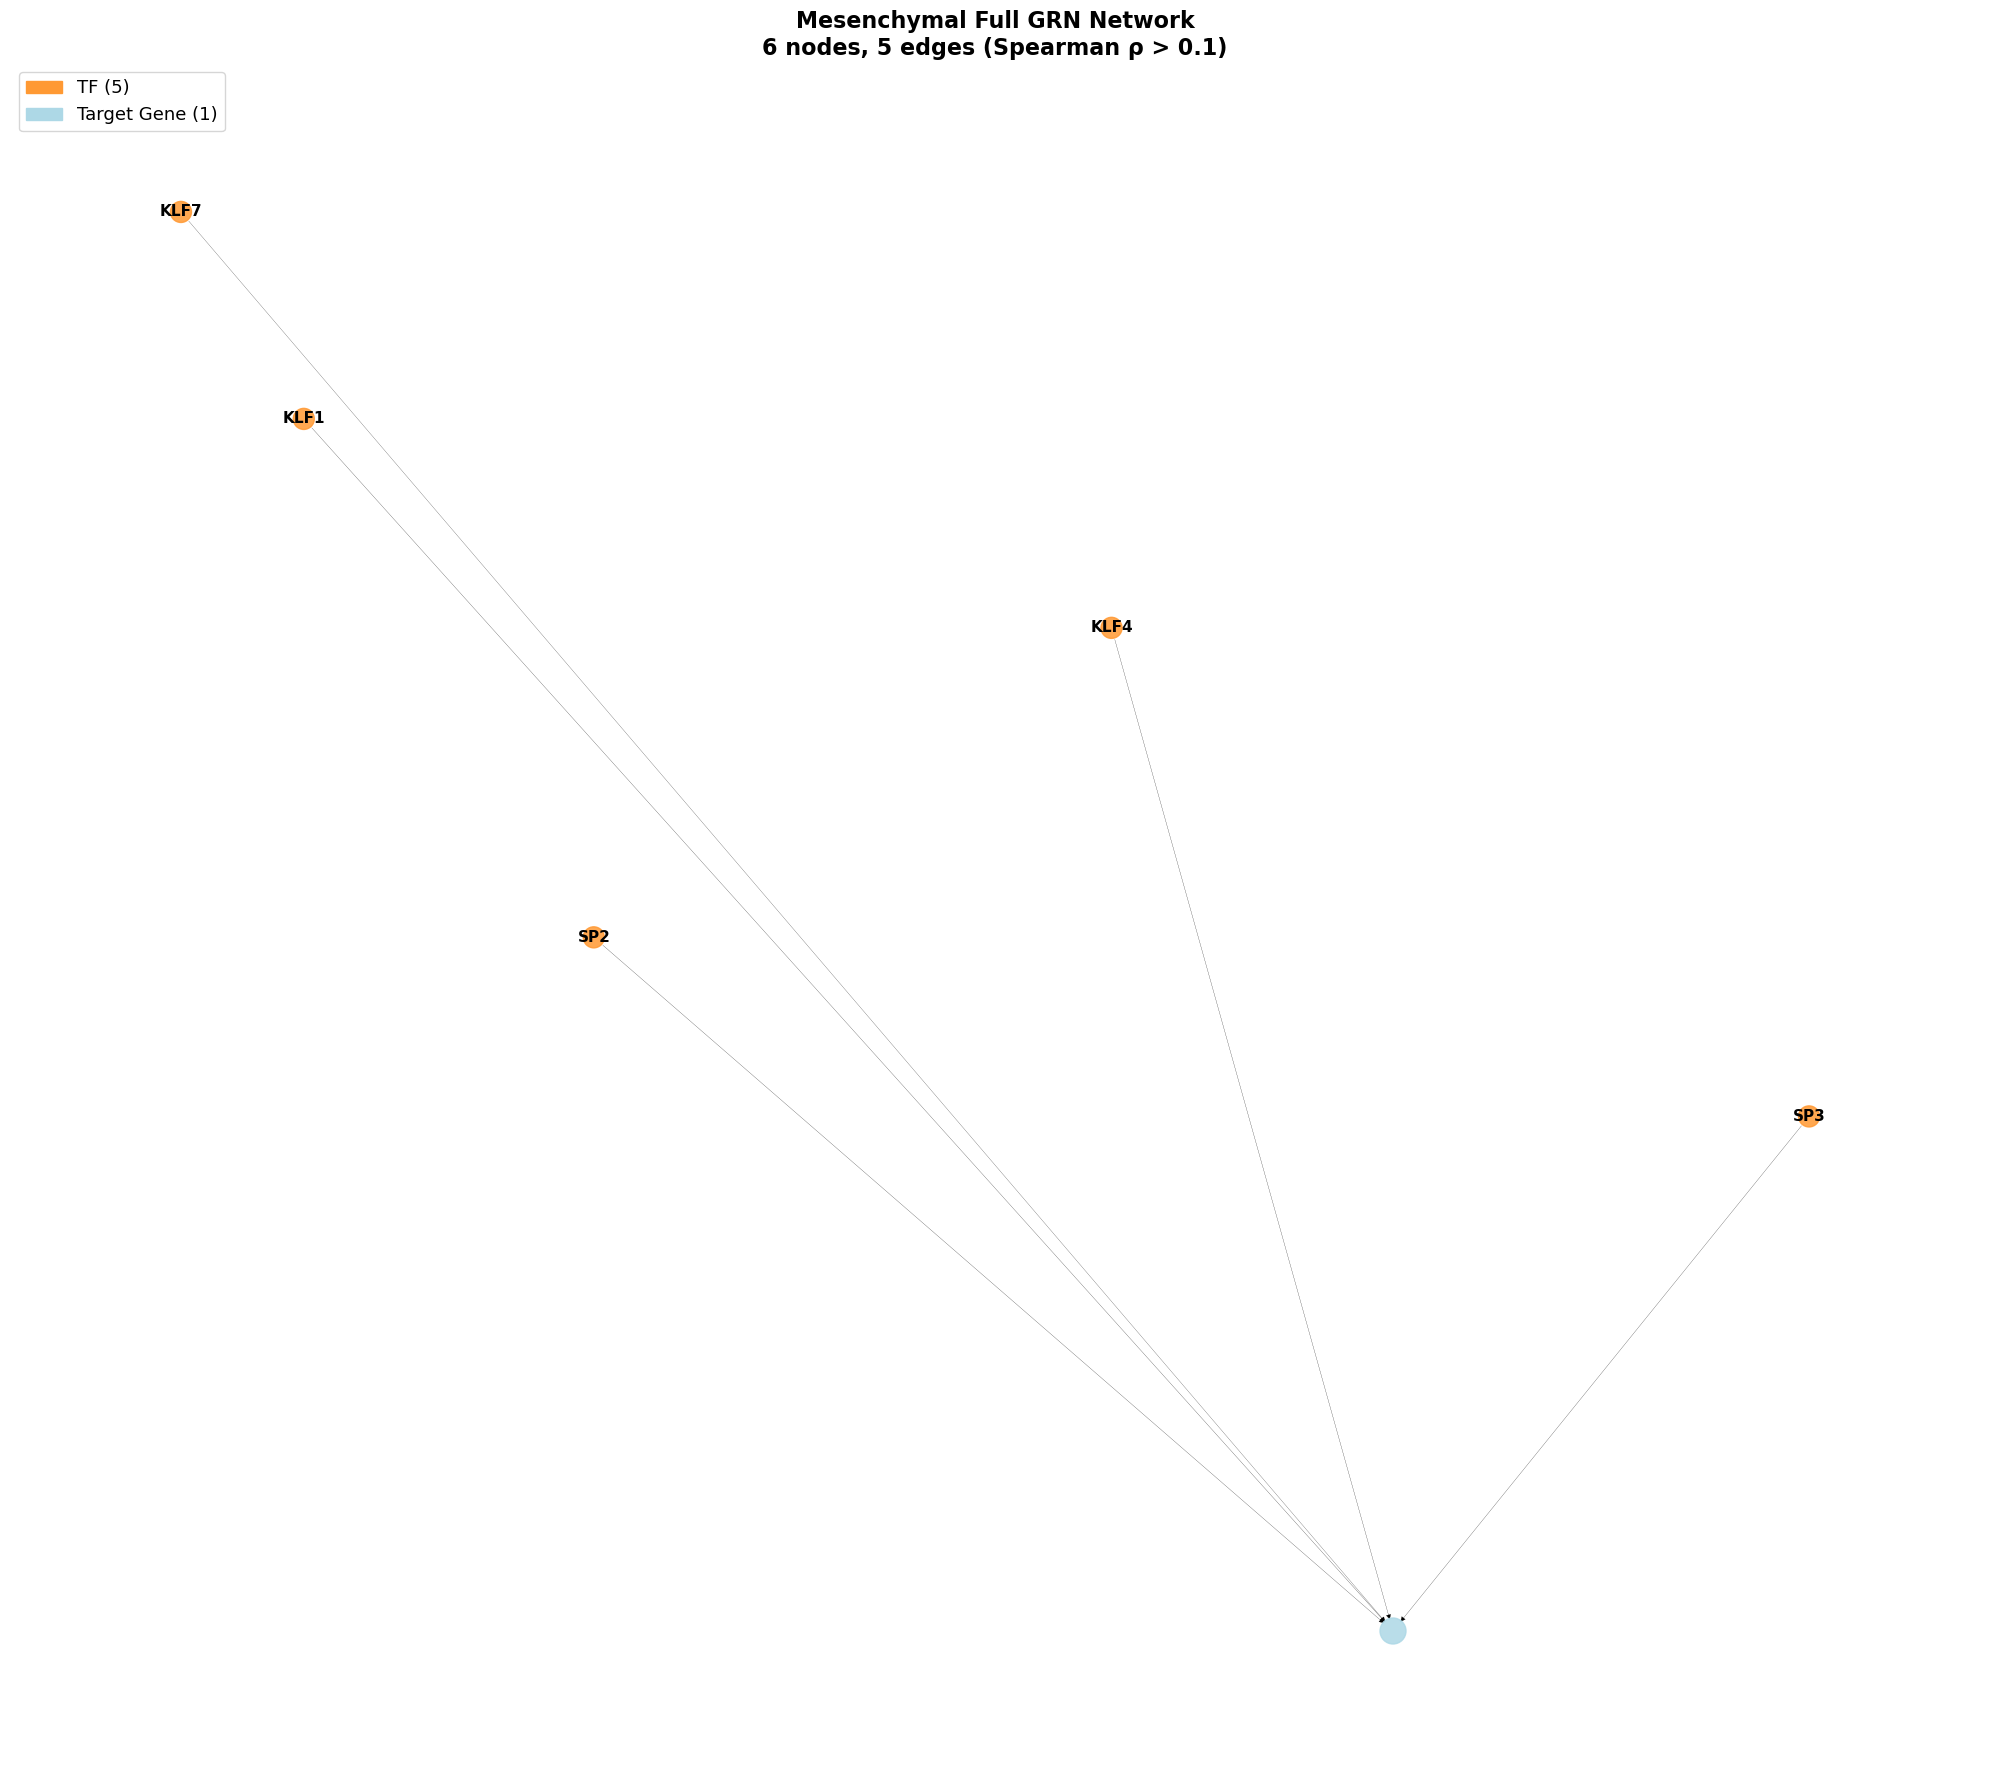

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 데이터 로드 및 필터링
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Mesenchymal_All_GRN_Weights.csv')
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 2. 전체 네트워크 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], grn_weight=row['grn_weight'])

# 3. 노드 속성
tfs = set(filtered_df['tf_name'])
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Top 10 TF (라벨 표시용)
top10_tfs = sorted([n for n in G.nodes() if n in tfs], key=lambda x: out_degree.get(x, 0), reverse=True)[:10]

# 4. 전체 네트워크 시각화
plt.figure(figsize=(20, 18))
pos = nx.spring_layout(G, k=0.15, iterations=80, seed=42)

# 노드 색상, 크기
node_color = ['#FF9933' if n in tfs else '#ADD8E6' for n in G.nodes()]
node_size = []
for n in G.nodes():
    if n in tfs:
        node_size.append(out_degree.get(n, 1) * 30 + 200)
    else:
        node_size.append(in_degree.get(n, 1) * 60 + 50)

# 에지
weights = [d['grn_weight'] * 1.5 for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#000000', alpha=1, arrowsize=8)

# 노드
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.85)

# 라벨: Top 10 TF만
labels = {n: n for n in top10_tfs}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')

# 범례
orange_patch = mpatches.Patch(color='#FF9933', label=f'TF ({len([n for n in G.nodes() if n in tfs])})')
blue_patch = mpatches.Patch(color='#ADD8E6', label=f'Target Gene ({len([n for n in G.nodes() if n not in tfs])})')
plt.legend(handles=[orange_patch, blue_patch], fontsize=13, loc='upper left')

plt.title(f'Mesenchymal Full GRN Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges (Spearman ρ > 0.1)',
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Macrophage

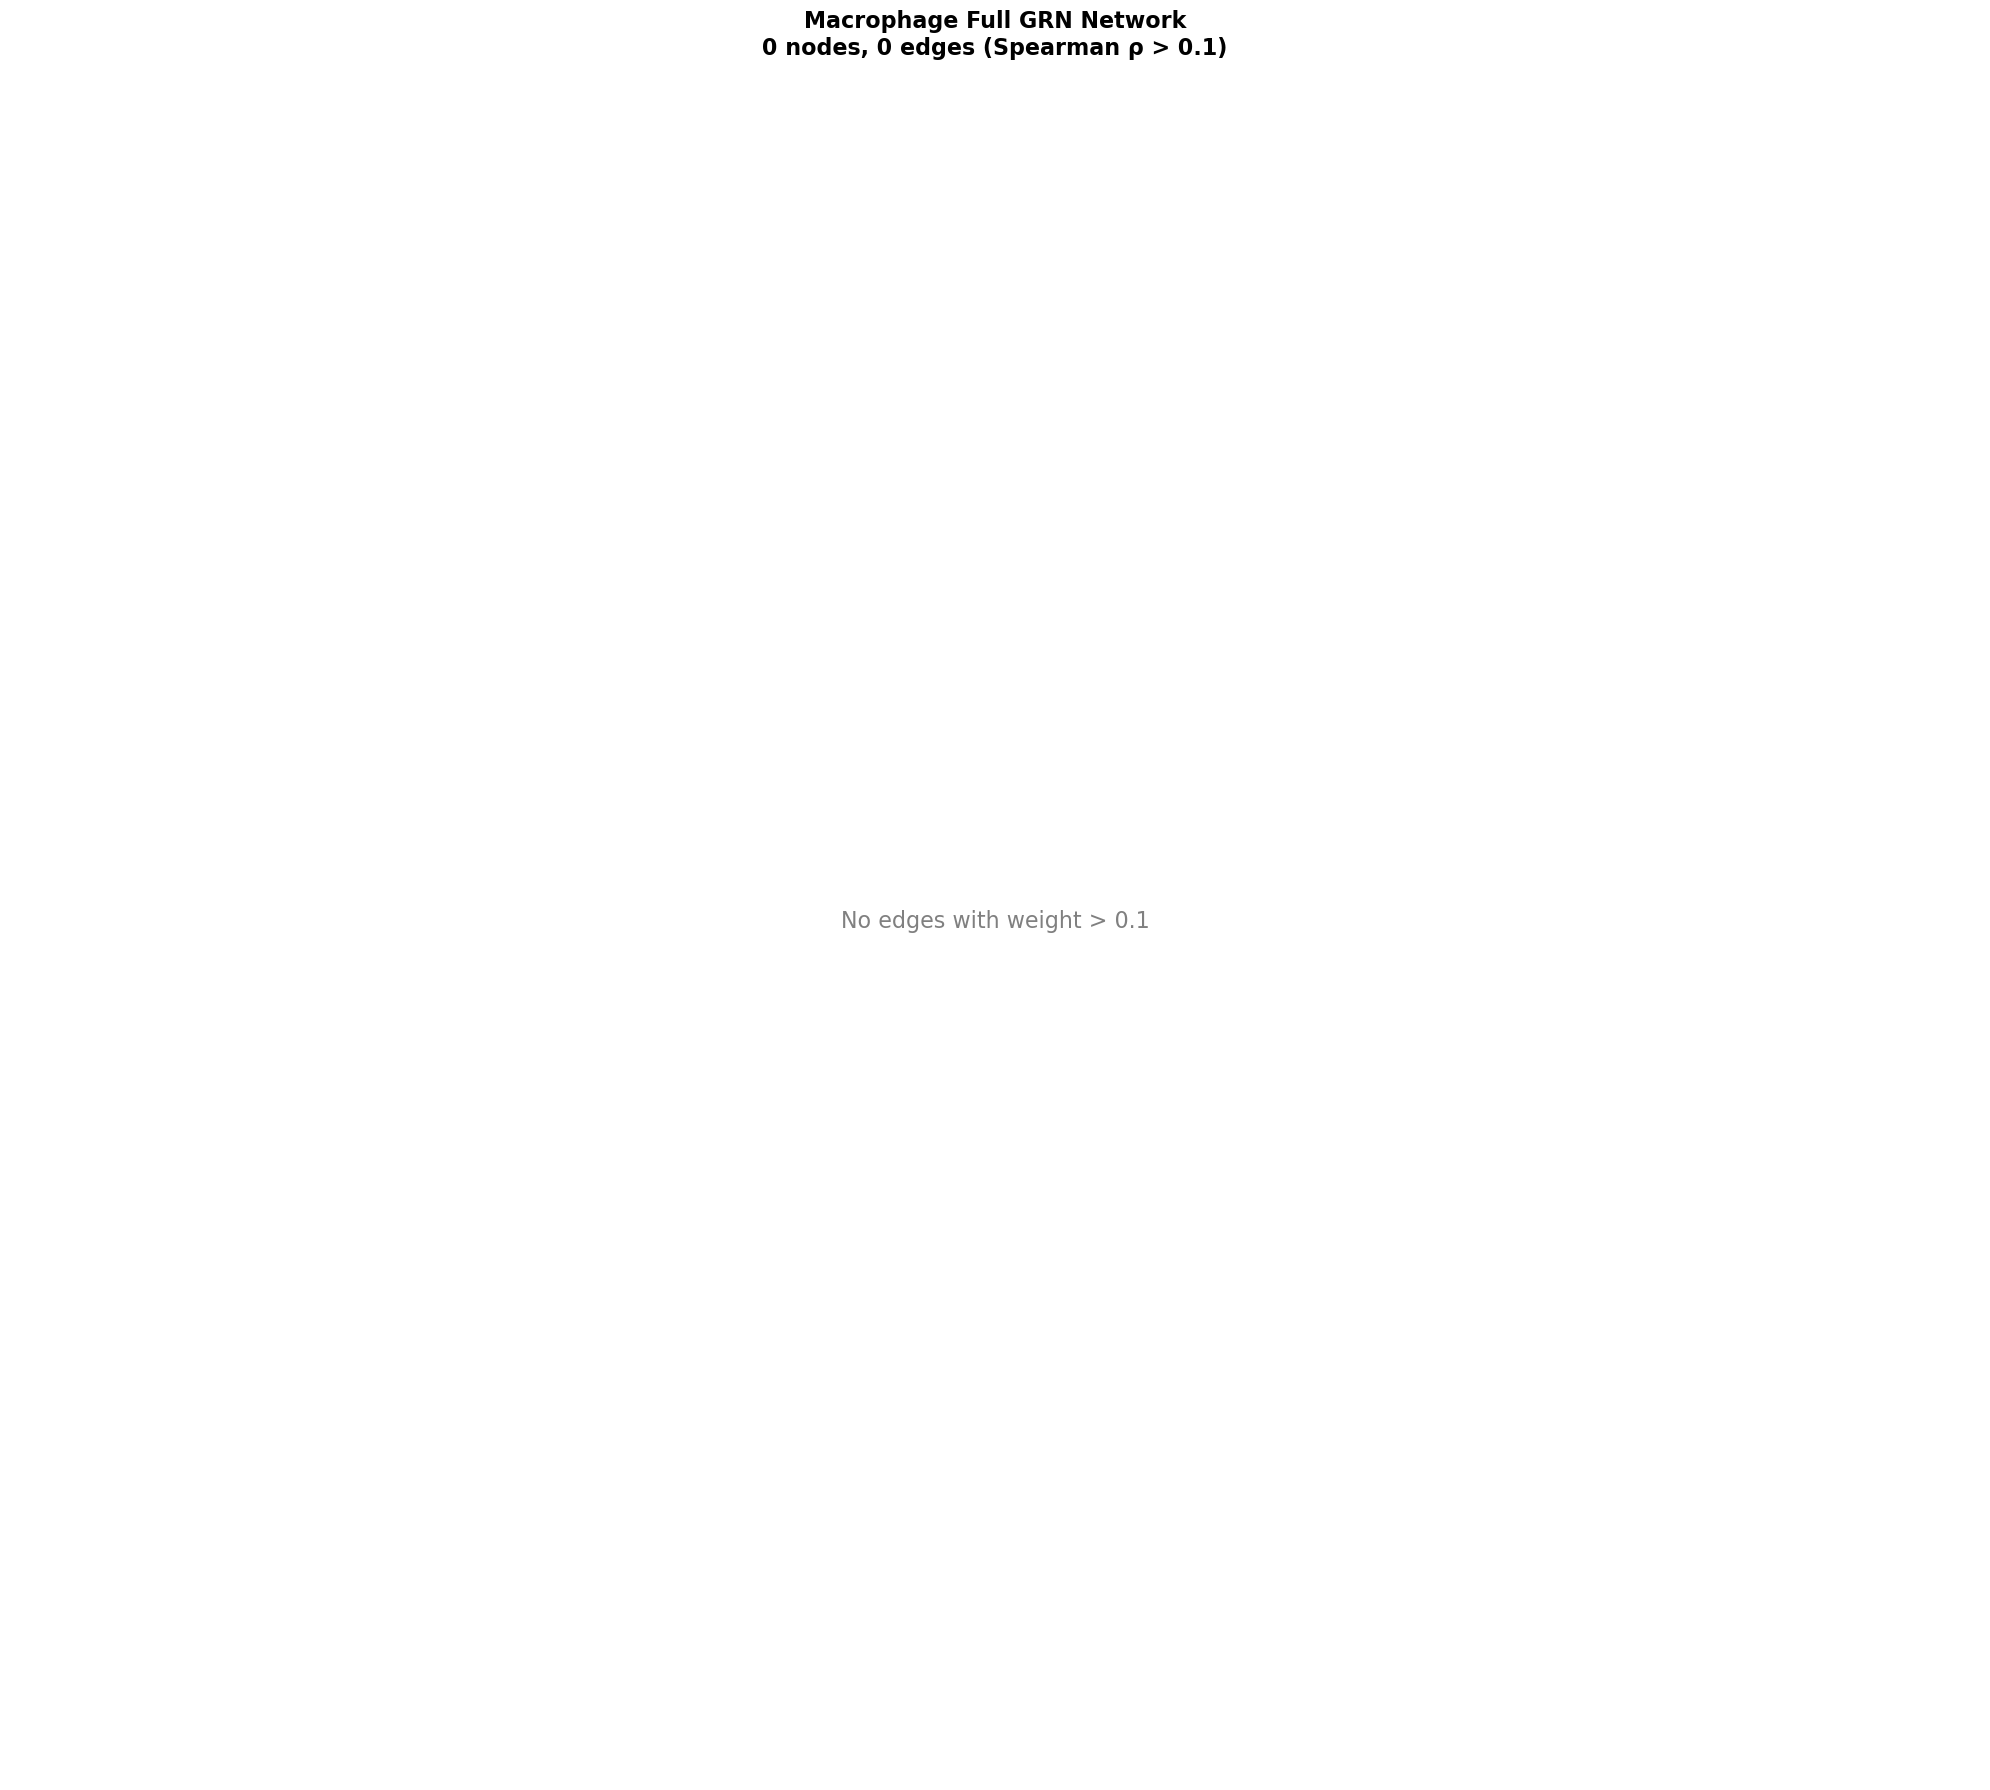

In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 데이터 로드 및 필터링
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Macrophages_All_GRN_Weights.csv')
filtered_df = df[df['grn_weight'] > 0.1].copy()

if len(filtered_df) == 0:
    plt.figure(figsize=(20, 18))
    plt.text(0.5, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=16, color='grey')
    plt.title('Macrophage Full GRN Network\n0 nodes, 0 edges (Spearman ρ > 0.1)',
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    # 2. 전체 네트워크 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], grn_weight=row['grn_weight'])

    # 3. 노드 속성
    tfs = set(filtered_df['tf_name'])
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    # Top 10 TF (라벨 표시용)
    top10_tfs = sorted([n for n in G.nodes() if n in tfs], key=lambda x: out_degree.get(x, 0), reverse=True)[:10]

    # 4. 전체 네트워크 시각화
    plt.figure(figsize=(20, 18))
    pos = nx.spring_layout(G, k=0.15, iterations=80, seed=42)

    # 노드 색상, 크기
    node_color = ['#FF9933' if n in tfs else '#ADD8E6' for n in G.nodes()]
    node_size = []
    for n in G.nodes():
        if n in tfs:
            node_size.append(out_degree.get(n, 1) * 30 + 200)
        else:
            node_size.append(in_degree.get(n, 1) * 60 + 50)

    # 에지
    weights = [d['grn_weight'] * 1.5 for _, _, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='#000000', alpha=1, arrowsize=8)

    # 노드
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.85)

    # 라벨: Top 10 TF만
    labels = {n: n for n in top10_tfs}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')

    # 범례
    orange_patch = mpatches.Patch(color='#FF9933', label=f'TF ({len([n for n in G.nodes() if n in tfs])})')
    blue_patch = mpatches.Patch(color='#ADD8E6', label=f'Target Gene ({len([n for n in G.nodes() if n not in tfs])})')
    plt.legend(handles=[orange_patch, blue_patch], fontsize=13, loc='upper left')

    plt.title(f'Macrophage Full GRN Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges (Spearman ρ > 0.1)',
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## T Cell

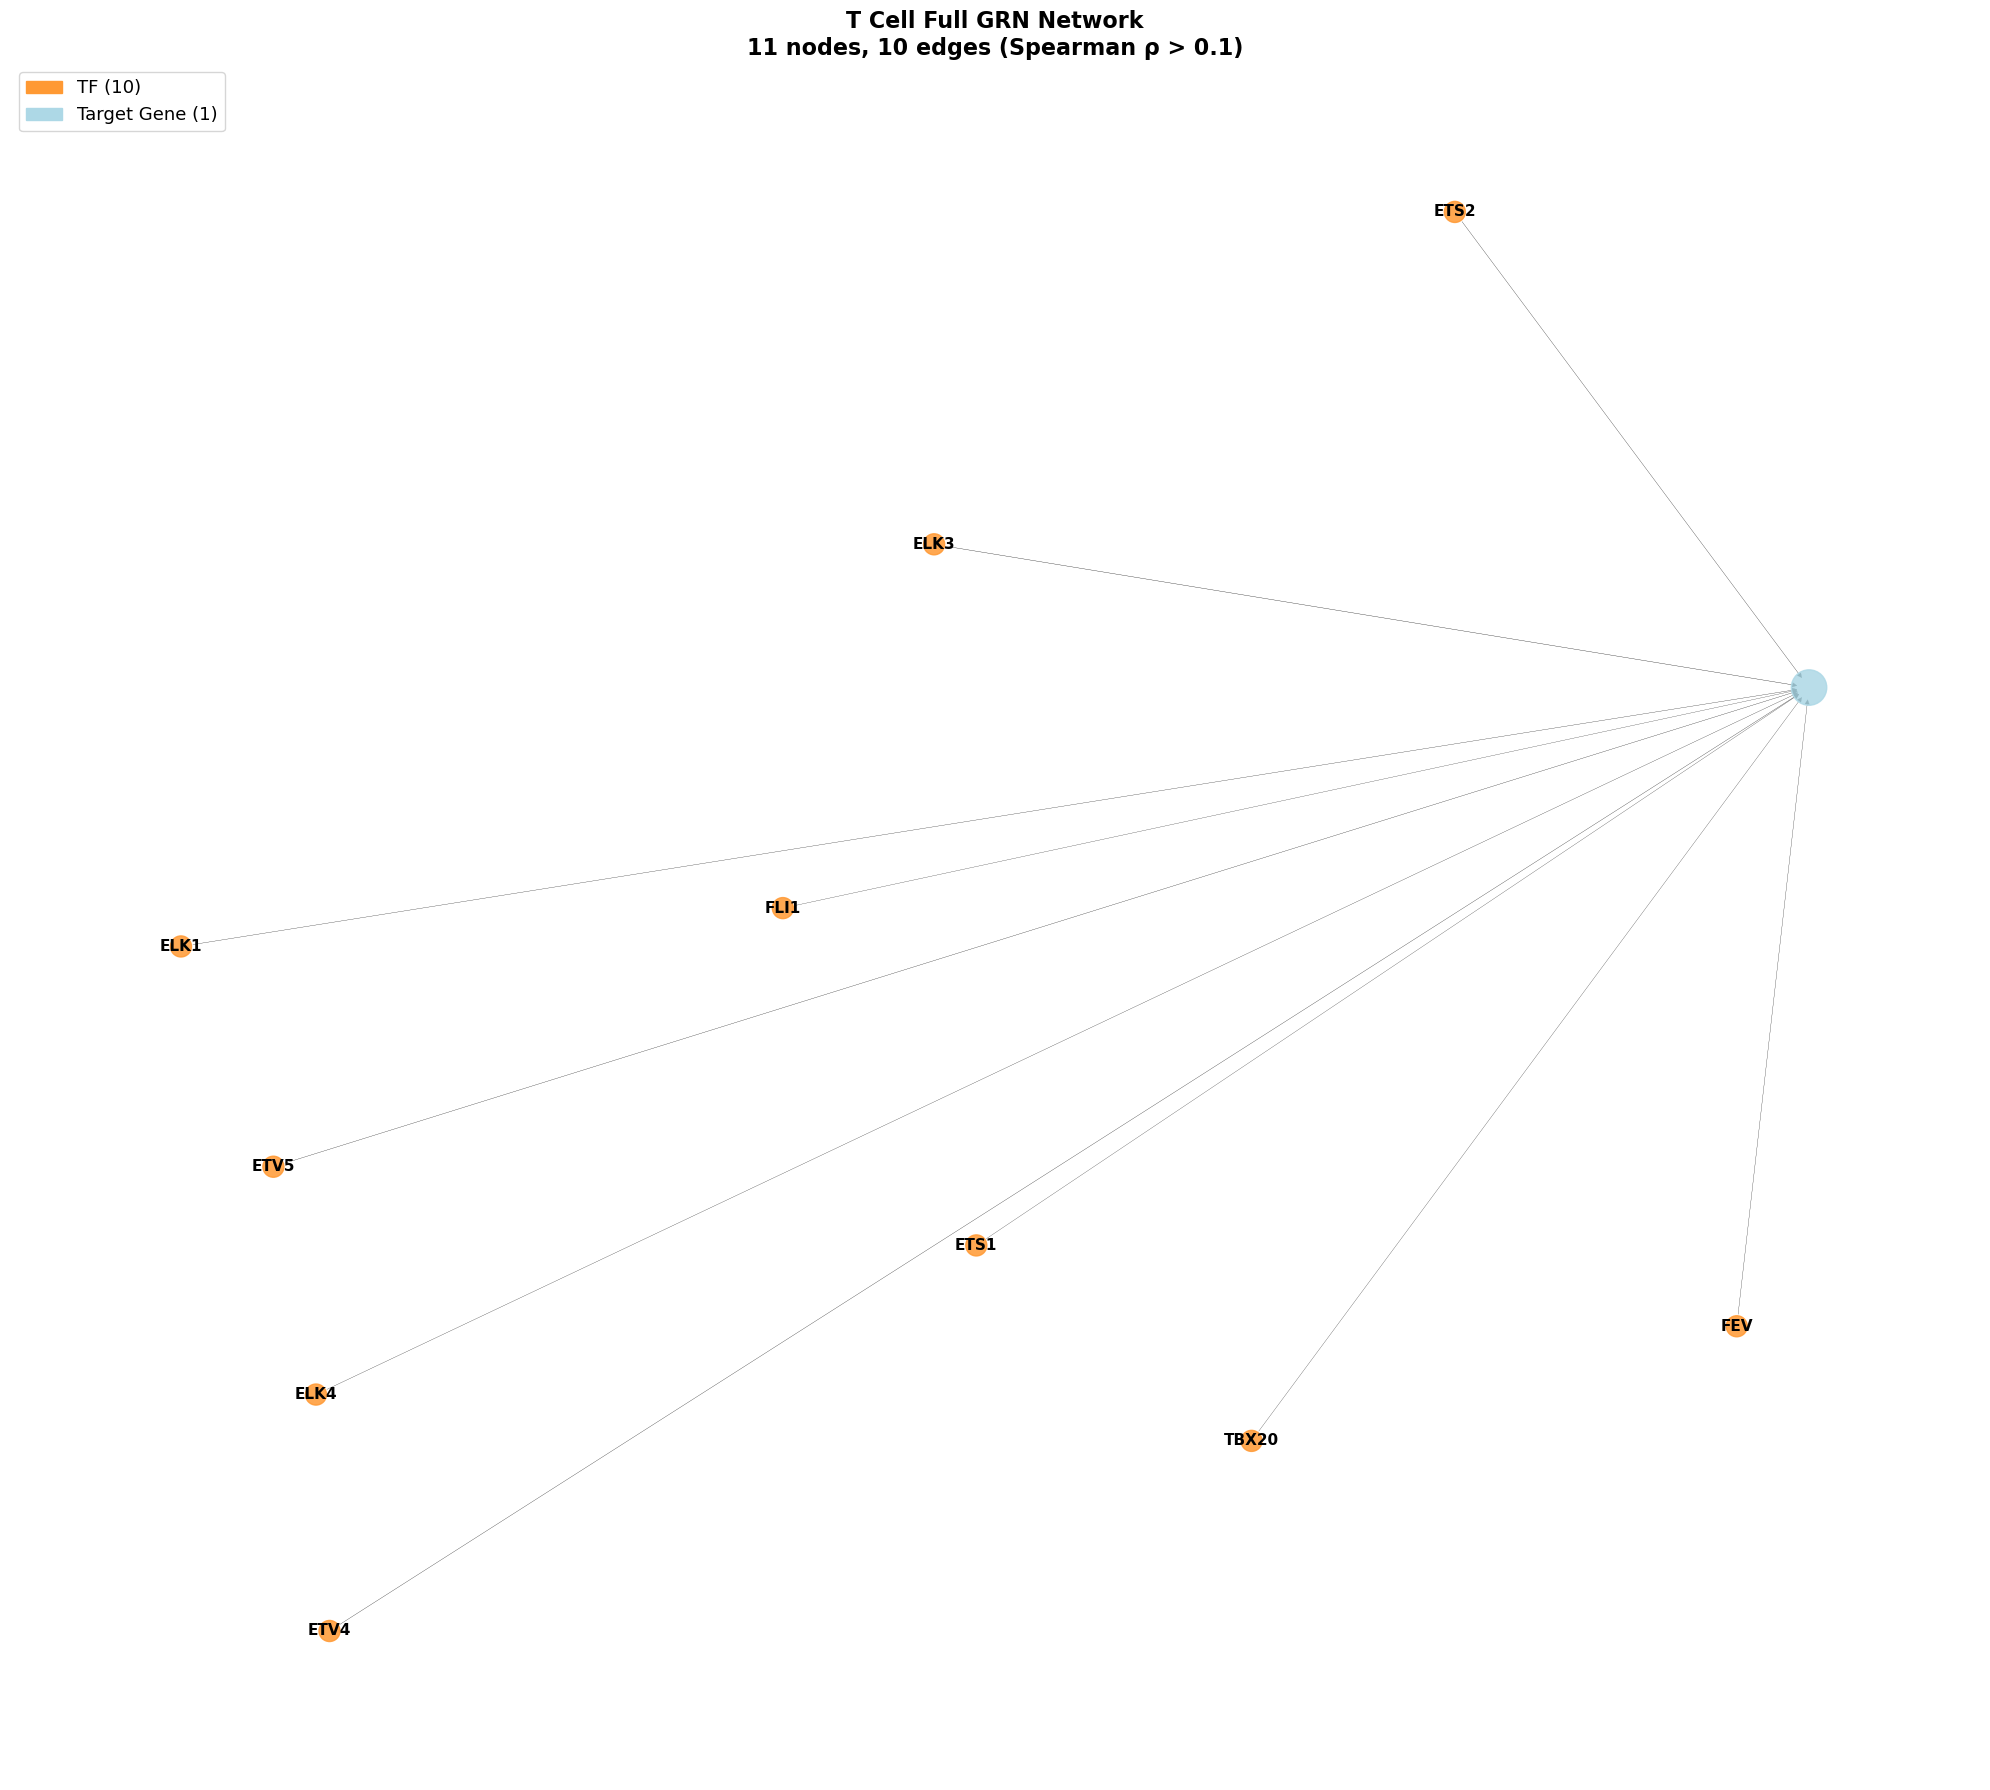

In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 데이터 로드 및 필터링
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/T_Cells_All_GRN_Weights.csv')
filtered_df = df[df['grn_weight'] > 0.1].copy()

# 2. 전체 네트워크 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], grn_weight=row['grn_weight'])

# 3. 노드 속성
tfs = set(filtered_df['tf_name'])
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Top 10 TF (라벨 표시용)
top10_tfs = sorted([n for n in G.nodes() if n in tfs], key=lambda x: out_degree.get(x, 0), reverse=True)[:10]

# 4. 전체 네트워크 시각화
plt.figure(figsize=(20, 18))
pos = nx.spring_layout(G, k=0.15, iterations=80, seed=42)

# 노드 색상, 크기
node_color = ['#FF9933' if n in tfs else '#ADD8E6' for n in G.nodes()]
node_size = []
for n in G.nodes():
    if n in tfs:
        node_size.append(out_degree.get(n, 1) * 30 + 200)
    else:
        node_size.append(in_degree.get(n, 1) * 60 + 50)

# 에지
weights = [d['grn_weight'] * 1.5 for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#000000', alpha=1, arrowsize=8)

# 노드
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.85)

# 라벨: Top 10 TF만
labels = {n: n for n in top10_tfs}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')

# 범례
orange_patch = mpatches.Patch(color='#FF9933', label=f'TF ({len([n for n in G.nodes() if n in tfs])})')
blue_patch = mpatches.Patch(color='#ADD8E6', label=f'Target Gene ({len([n for n in G.nodes() if n not in tfs])})')
plt.legend(handles=[orange_patch, blue_patch], fontsize=13, loc='upper left')

plt.title(f'T Cell Full GRN Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges (Spearman ρ > 0.1)',
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## NK Cell

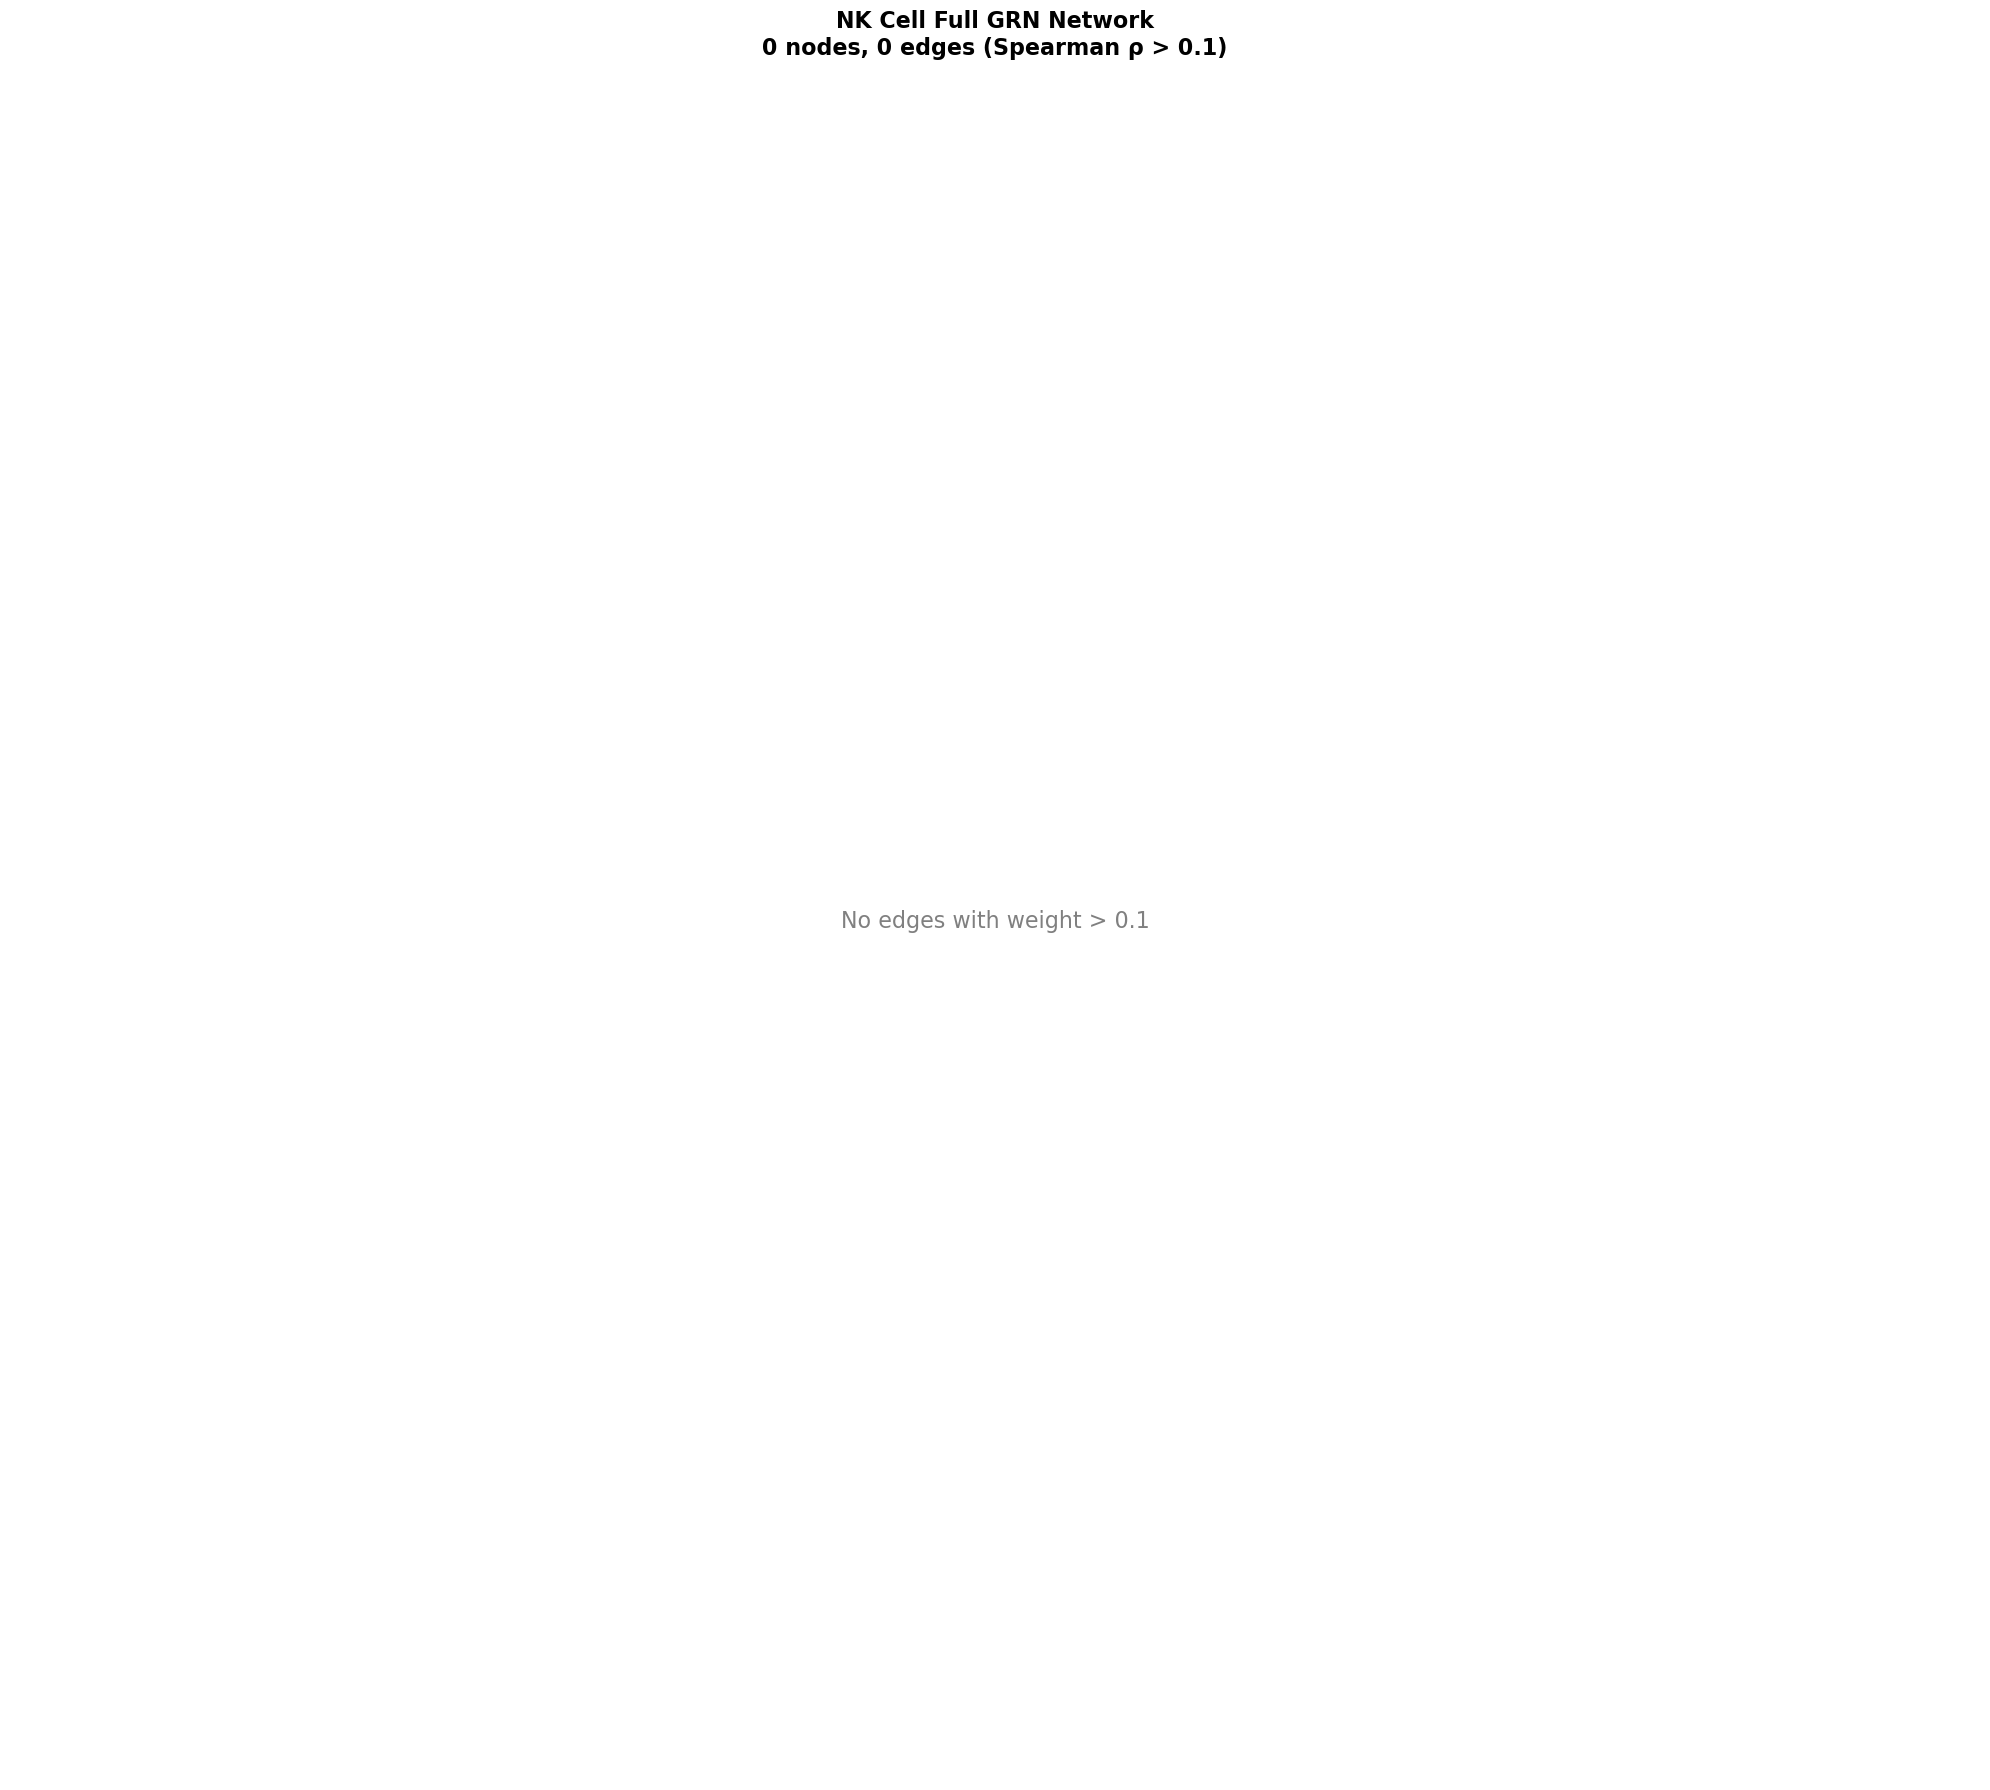

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 데이터 로드 및 필터링
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/NK_Cells_All_GRN_Weights.csv')
filtered_df = df[df['grn_weight'] > 0.1].copy()

if len(filtered_df) == 0:
    plt.figure(figsize=(20, 18))
    plt.text(0.5, 0.5, 'No edges with weight > 0.1', ha='center', va='center', fontsize=16, color='grey')
    plt.title('NK Cell Full GRN Network\n0 nodes, 0 edges (Spearman ρ > 0.1)',
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    # 2. 전체 네트워크 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], grn_weight=row['grn_weight'])

    # 3. 노드 속성
    tfs = set(filtered_df['tf_name'])
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    # Top 10 TF (라벨 표시용)
    top10_tfs = sorted([n for n in G.nodes() if n in tfs], key=lambda x: out_degree.get(x, 0), reverse=True)[:10]

    # 4. 전체 네트워크 시각화
    plt.figure(figsize=(20, 18))
    pos = nx.spring_layout(G, k=0.15, iterations=80, seed=42)

    # 노드 색상, 크기
    node_color = ['#FF9933' if n in tfs else '#ADD8E6' for n in G.nodes()]
    node_size = []
    for n in G.nodes():
        if n in tfs:
            node_size.append(out_degree.get(n, 1) * 30 + 200)
        else:
            node_size.append(in_degree.get(n, 1) * 60 + 50)

    # 에지
    weights = [d['grn_weight'] * 1.5 for _, _, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='#000000', alpha=1, arrowsize=8)

    # 노드
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, alpha=0.85)

    # 라벨: Top 10 TF만
    labels = {n: n for n in top10_tfs}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')

    # 범례
    orange_patch = mpatches.Patch(color='#FF9933', label=f'TF ({len([n for n in G.nodes() if n in tfs])})')
    blue_patch = mpatches.Patch(color='#ADD8E6', label=f'Target Gene ({len([n for n in G.nodes() if n not in tfs])})')
    plt.legend(handles=[orange_patch, blue_patch], fontsize=13, loc='upper left')

    plt.title(f'NK Cell Full GRN Network\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges (Spearman ρ > 0.1)',
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()